Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='object')

RQ1 Table:
  Subscription_Tier  Revenue_Generated
0             Basic       1.713394e+08
1           Premium       1.645059e+08
2          Standard       1.645410e+08


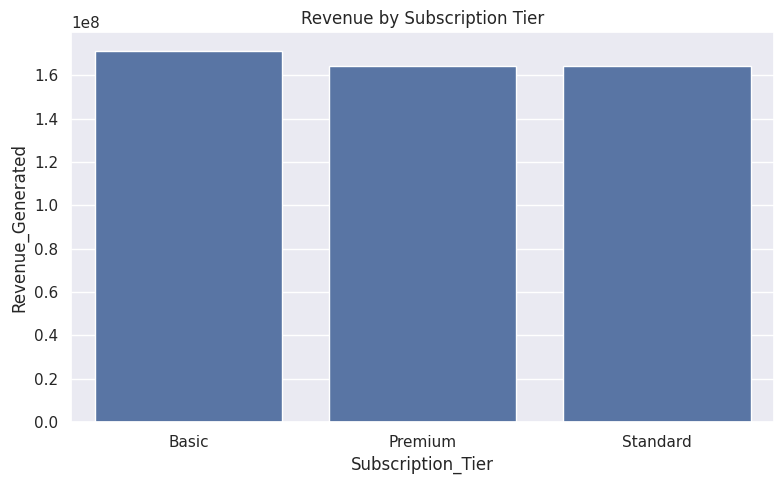

In [12]:
# RQ1 - revenue by subscription tier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("/content/marketing_and_product_performance.csv")

print(df.columns)

df = df.drop_duplicates().dropna()

# Correcting columns
tier_col = "Subscription_Tier"
revenue_col = "Revenue_Generated"

# Aggregation
rq1 = df.groupby(tier_col)[revenue_col].sum().reset_index()

print("\nRQ1 Table:")
print(rq1)

rq1.to_csv("outputs/rq1_subscription_revenue.csv", index=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=rq1, x=tier_col, y=revenue_col)
plt.title("Revenue by Subscription Tier")
plt.tight_layout()

plt.savefig("outputs/rq1_subscription_revenue.pdf")

plt.show()

Columns: Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='object')

Correlation Table:
                   Budget  Revenue_Generated
Budget             1.0000            -0.0215
Revenue_Generated -0.0215             1.0000


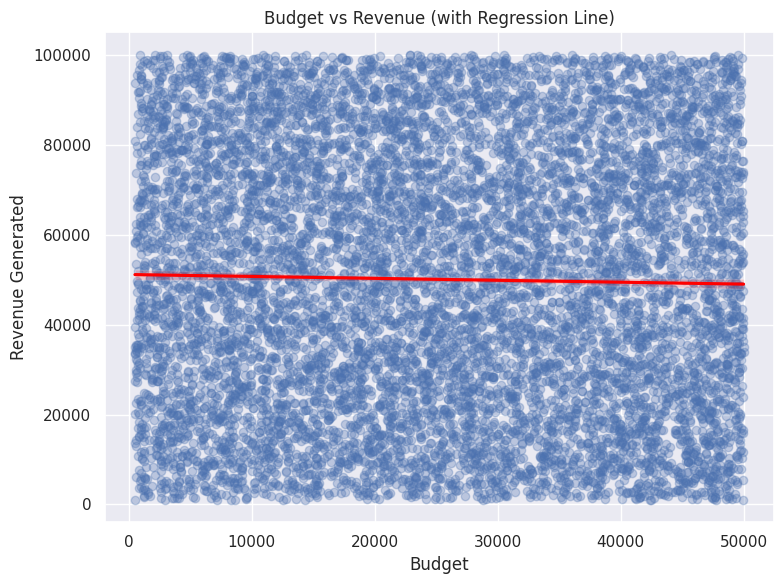


Interpretation:
The correlation between Budget and Revenue is -0.0215, indicating a very weak or no linear relationship.


In [14]:
# RQ2 - relationship b/w budget and revenue


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Creating output folder
os.makedirs("outputs", exist_ok=True)

# Loading dataset
df = pd.read_csv("/content/marketing_and_product_performance.csv")

# Preview columns
print("Columns:", df.columns)

# Data cleaning
df = df.drop_duplicates()
df = df.dropna()

# Selecting columns
df_rq2 = df[["Budget", "Revenue_Generated"]]

#Correlation Table
corr = df_rq2.corr()

pd.options.display.float_format = '{:,.4f}'.format

print("\nCorrelation Table:")
print(corr)

# Save table
corr.to_csv("outputs/rq2_correlation.csv")

# Scatter plot + Regression line
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_rq2,
    x="Budget",
    y="Revenue_Generated",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Budget vs Revenue (with Regression Line)")
plt.xlabel("Budget")
plt.ylabel("Revenue Generated")

plt.tight_layout()

# Saving figure
plt.savefig("outputs/rq2_budget_vs_revenue.pdf")

plt.show()

#Interpretation output

corr_value = corr.loc["Budget", "Revenue_Generated"]

print("\nInterpretation:")
print(f"The correlation between Budget and Revenue is {corr_value:.4f}, indicating a very weak or no linear relationship.")


RQ3 Table:
  Discount_Bin  Units_Sold
0         0-20      185776
1        21-40      335076
2        41-60      338835
3        61-80      147209


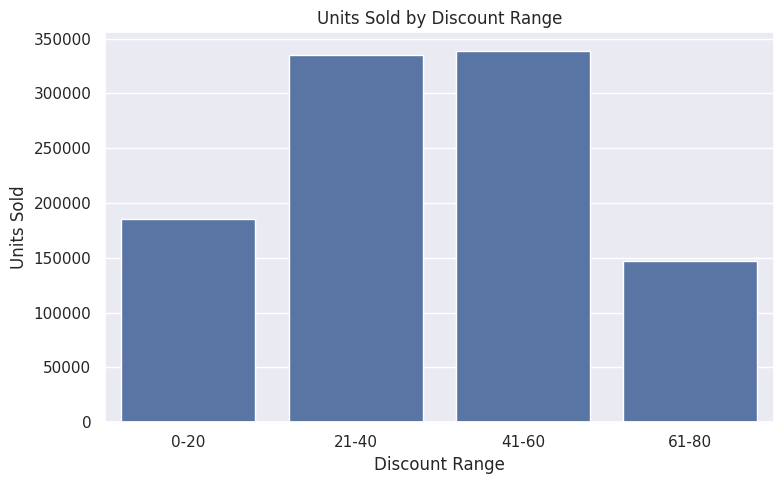

In [17]:
# RQ3: Discount Level vs Units Sold
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("/content/marketing_and_product_performance.csv")
df = df.drop_duplicates().dropna()

# Creating bins for discount levels
bins = [0, 20, 40, 60, 80]
labels = ["0-20", "21-40", "41-60", "61-80"]

df["Discount_Bin"] = pd.cut(df["Discount_Level"], bins=bins, labels=labels)

# Grouped data
rq3 = df.groupby("Discount_Bin", observed=False)["Units_Sold"].sum().reset_index()
print("\nRQ3 Table:")
print(rq3)

# Save table
rq3.to_csv("outputs/rq3_discount_bins.csv", index=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=rq3, x="Discount_Bin", y="Units_Sold")

plt.title("Units Sold by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.savefig("outputs/rq3_discount_bins.pdf")

plt.show()


RQ4 Table (Mean Revenue):
   Customer_Satisfaction_Post_Refund  Revenue_Generated
0                                  1        50,102.0100
1                                  2        50,179.2200
2                                  3        49,896.8000
3                                  4        49,970.8700


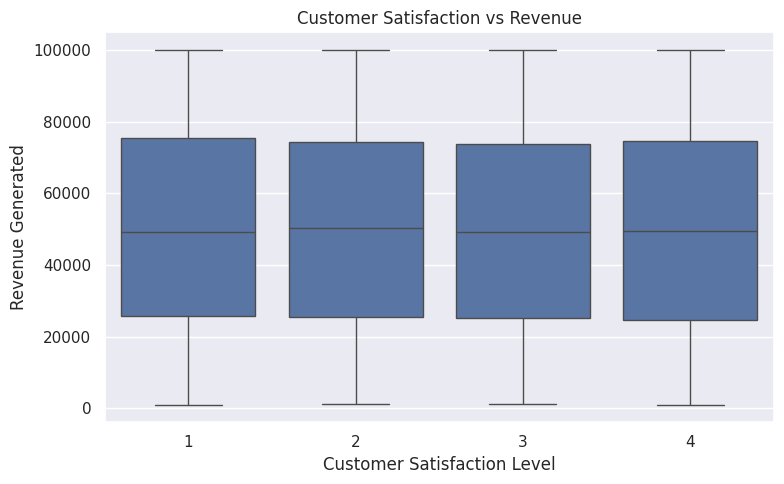


Interpretation:
Revenue is nearly constant across all satisfaction levels, indicating no strong relationship.


In [19]:
# 1. Aggregation
rq4 = df.groupby("Customer_Satisfaction_Post_Refund", observed=False)["Revenue_Generated"].mean().reset_index()

# Formating for readability
rq4["Revenue_Generated"] = rq4["Revenue_Generated"].round(2)

print("\nRQ4 Table (Mean Revenue):")
print(rq4)

# Save table
rq4.to_csv("outputs/rq4_satisfaction_revenue.csv", index=False)

#Boxplot Visualization

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Customer_Satisfaction_Post_Refund",
    y="Revenue_Generated"
)

plt.title("Customer Satisfaction vs Revenue")
plt.xlabel("Customer Satisfaction Level")
plt.ylabel("Revenue Generated")

plt.tight_layout()

# Save figure
plt.savefig("outputs/rq4_satisfaction_boxplot.pdf")

plt.show()

# Interpretation Output

mean_values = rq4["Revenue_Generated"].values

print("\nInterpretation:")

if max(mean_values) - min(mean_values) < 1000:
    print("Revenue is nearly constant across all satisfaction levels, indicating no strong relationship.")
else:
    print("There is variation in revenue across satisfaction levels.")


Sample Data:
   Bundle_Price  Units_Sold
0      433.8000          34
1      289.2900          97
2      462.8700         160
3      334.1600         159
4      371.6700          52


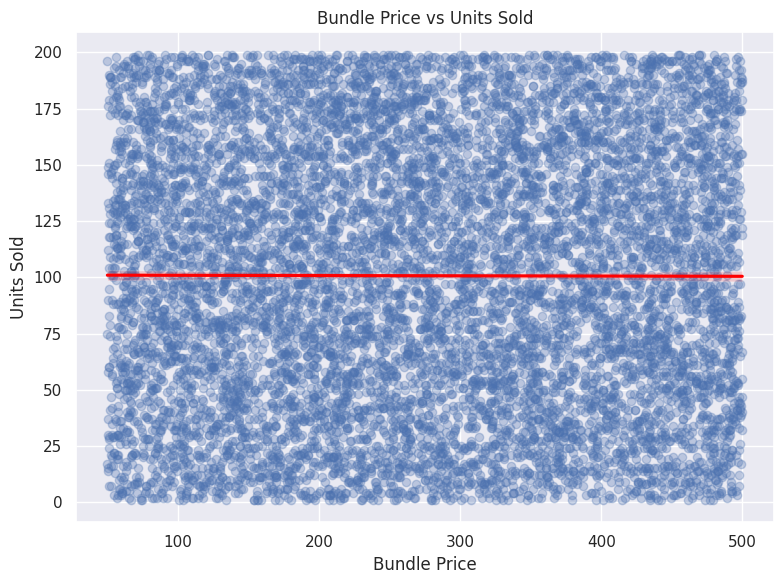


Correlation:
              Bundle_Price  Units_Sold
Bundle_Price        1.0000     -0.0025
Units_Sold         -0.0025      1.0000


In [21]:
rq5 = df[["Bundle_Price", "Units_Sold"]]

rq5.to_csv("outputs/rq5_bundle_vs_sales.csv", index=False)

print("\nSample Data:")
print(rq5.head())


# Improved visualization
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Bundle_Price",
    y="Units_Sold",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Bundle Price vs Units Sold")
plt.xlabel("Bundle Price")
plt.ylabel("Units Sold")

plt.tight_layout()

# Save figure
plt.savefig("outputs/rq5_bundle_vs_sales.pdf")
plt.show()

#Correlation

corr = df[["Bundle_Price", "Units_Sold"]].corr()

print("\nCorrelation:")
print(corr)


Conversion Rate Statistics:
count   9,041.0000
mean        0.2379
std         0.2057
min         0.0002
25%         0.0899
50%         0.1824
75%         0.3147
max         1.0000
Name: Conversion_Rate, dtype: float64


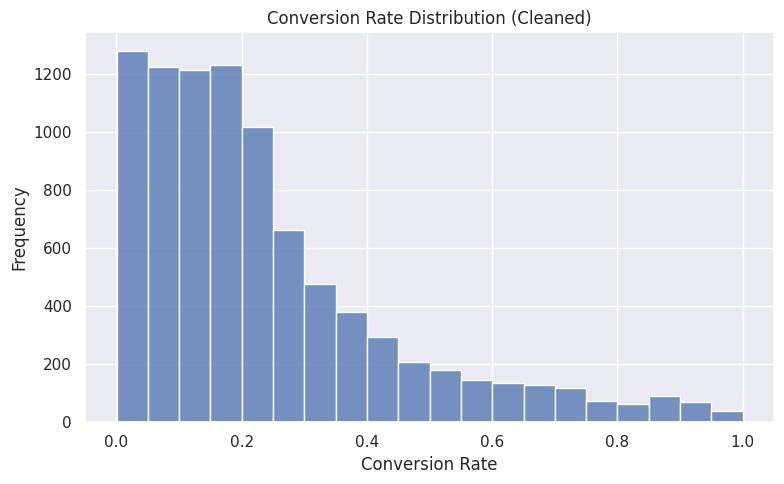

In [23]:
# Calculating conversion rate
df["Conversion_Rate"] = df["Conversions"] / df["Clicks"]

# Removing unrealistic values (>1)
df = df[df["Conversion_Rate"] <= 1]
stats = df["Conversion_Rate"].describe()

pd.options.display.float_format = '{:,.4f}'.format

print("\nConversion Rate Statistics:")
print(stats)

# Save table
stats.to_csv("outputs/rq6_conversion_stats.csv")

#Histogram
plt.figure(figsize=(8,5))

sns.histplot(df["Conversion_Rate"], bins=20)

plt.title("Conversion Rate Distribution (Cleaned)")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("outputs/rq6_conversion_histogram.pdf")

plt.show()


RQ7 Table:
  Subscription_Tier    ROI
0             Basic 2.7910
1           Premium 2.7390
2          Standard 2.7380


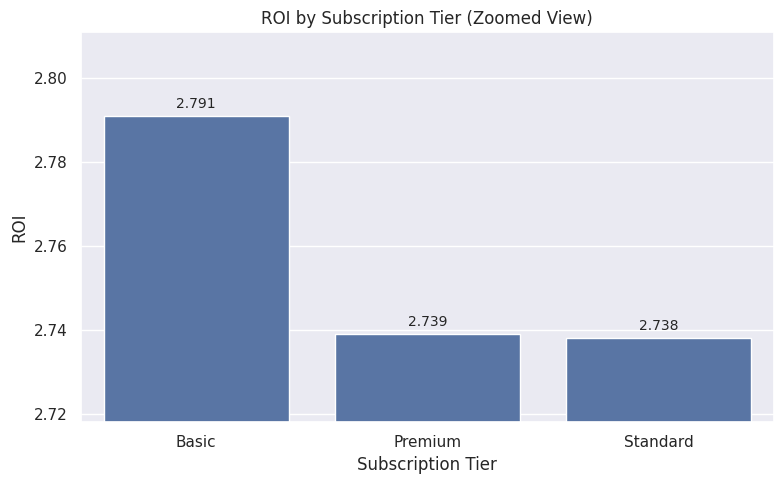


Interpretation:
ROI values are very similar across all subscription tiers, indicating minimal impact of tier on return on investment.


In [25]:
# RQ7 - ROI by subscription tier
rq7 = df.groupby("Subscription_Tier", observed=False)["ROI"].mean().reset_index()

# Round values for clarity
rq7["ROI"] = rq7["ROI"].round(3)

print("\nRQ7 Table:")
print(rq7)

# Save table
rq7.to_csv("outputs/rq7_roi.csv", index=False)

# Improved visualization
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=rq7,
    x="Subscription_Tier",
    y="ROI"
)

# Zooming y-axis to show differences clearly
plt.ylim(rq7["ROI"].min() - 0.02, rq7["ROI"].max() + 0.02)

# Adding value labels on bars
for i, val in enumerate(rq7["ROI"]):
    ax.text(i, val + 0.002, f"{val:.3f}", ha='center', fontsize=10)

plt.title("ROI by Subscription Tier (Zoomed View)")
plt.xlabel("Subscription Tier")
plt.ylabel("ROI")

plt.tight_layout()

# Save figure
plt.savefig("outputs/rq7_roi_improved.pdf")

plt.show()

#Interpretation
print("\nInterpretation:")
print("ROI values are very similar across all subscription tiers, indicating minimal impact of tier on return on investment.")

In [26]:

# Simple Regression Model (Required Fix)


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
df = pd.read_csv("/content/marketing_and_product_performance.csv")

df = df.drop_duplicates().dropna()

# Features & target
X = df[["Budget", "Clicks", "Conversions", "Discount_Level", "Units_Sold", "Bundle_Price"]]
y = df["Revenue_Generated"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 24732.080568319016
MSE: 816376204.9862359
RMSE: 28572.297859749324
R2 Score: -0.0011614854904129501



Linear Regression
MAE: 26248.74461032847
RMSE: 31198.30752908102
R2 Score: -0.19364687567046346

Decision Tree
MAE: 26341.999840671946
RMSE: 31379.34980144815
R2 Score: -0.20754042121498273

Random Forest
MAE: 26224.656772251456
RMSE: 31197.302227365428
R2 Score: -0.1935699512464426

Model Comparison:
               Model         MAE              MSE        RMSE  R2_Score
0  Linear Regression 26,248.7446 973,334,392.6791 31,198.3075   -0.1936
1      Decision Tree 26,341.9998 984,663,593.9616 31,379.3498   -0.2075
2      Random Forest 26,224.6568 973,271,666.2656 31,197.3022   -0.1936


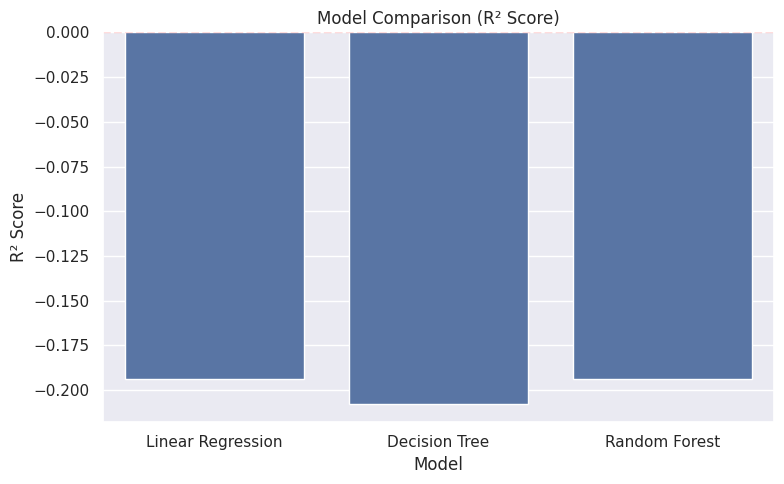

In [32]:

# Supervised Learning Models


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Create output folder
os.makedirs("outputs", exist_ok=True)

# Load dataset
df = pd.read_csv("/content/marketing_and_product_performance.csv")

# Clean data
df = df.drop_duplicates().dropna()


# Feature Selection

features = [
    "Budget",
    "Clicks",
    "Conversions",
    "Units_Sold"
]

X = df[features]
y = df["Revenue_Generated"]

# Log transform target
y = np.log1p(y)


# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Scaling (for Linear Regression)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = []


# Training & Evaluation

for name, model in models.items():

    # Use scaled data only for Linear Regression
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Convert back from log scale
    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(y_pred)

    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)

    results.append([name, mae, mse, rmse, r2])

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

# Results Table

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2_Score"]
)

print("\nModel Comparison:")
print(results_df)

# Save results
results_df.to_csv("outputs/model_comparison.csv", index=False)
# Visualization
plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x="Model", y="R2_Score")

# Adding baseline
plt.axhline(0, color='red', linestyle='--')

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")

plt.tight_layout()
plt.savefig("outputs/model_comparison.pdf")

plt.show()